In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# GEREKLİ PAKETLERİ YÜKLE
!pip install -q jpype1 gensim fasttext-wheel stanza scikit-learn tqdm

# Java ve Maven — Zemberek için
!apt-get install -y openjdk-17-jdk-headless maven -qq

import os

#ZEMBEREK — yoksa GitHub'dan derle
ZEMBEREK_JAR = '/content/zemberek-nlp/all/target/zemberek-full.jar'

if not os.path.exists(ZEMBEREK_JAR):
    !git clone --depth=1 https://github.com/ahmetaa/zemberek-nlp.git
    !cd zemberek-nlp && mvn -q -DskipTests package

# FASTTEXT — Türkçe önceden eğitilmiş model
FT_MODEL = '/content/drive/MyDrive/cc.tr.300.bin'

if not os.path.exists(FT_MODEL):
    # 4.2GB, bir kere indir Drive'a kaydet
    !wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.tr.300.bin.gz
    !gunzip cc.tr.300.bin.gz

#JVM BAŞLAT — Zemberek içn
import jpype
if not jpype.isJVMStarted():
    jpype.startJVM(classpath=[ZEMBEREK_JAR])

TurkishMorphology = jpype.JClass('zemberek.morphology.TurkishMorphology')
morphology = TurkishMorphology.createWithDefaults()
# === FASTTEXT YÜKLE ===
import fasttext
ft_model = fasttext.load_model(FT_MODEL)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 121.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 5.8 MB/s eta 0:00:00
Extracting templates from packages: 100%
Selecting previously unselected package libapache-pom-java.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../00-libapache-pom-java_18-1_all.deb ...
Unpacking libapache-pom-java (18-1) ...
Selecting previously unselected package libatinject-jsr330-api-java.
Preparing to unp

In [3]:
# === VERİ YÜKLE ===
import pandas as pd
DOSYA = '/content/drive/MyDrive/Turkish_IMDB_Dataset.csv'

df = pd.read_csv(DOSYA, encoding='utf-8')
df.columns = [c.strip() for c in df.columns]
df = df.dropna().reset_index(drop=True)

# Sütunları göster — kullanıcı karar verir
print(f"{len(df)} satır, {len(df.columns)} sütun")
print("\nSütunlar ve örnek değerler:")
for i, col in enumerate(df.columns):
    ornek = df[col].dropna().iloc[0] if not df[col].dropna().empty else 'boş'
    print(f"  [{i}] {col:<20} → {str(ornek)[:50]}")

# Kullanıcı burayı doldurur
METIN_SUTUNU  = input("\nMetin sütunu adı: ").strip()
ETIKET_SUTUNU = input("Etiket sütunu adı: ").strip()

print("\nGörev seçin:")
print("  [1] Duygu analizi")
print("  [2] Haber sınıflandırma")
print("  [3] Genel")
secim = input("Seçim (1/2/3): ").strip()
GOREV = {'1': 'duygu_analizi', '2': 'haber', '3': 'genel'}.get(secim, 'genel')

df = df.dropna(subset=[METIN_SUTUNU]).reset_index(drop=True)

49366 satır, 2 sütun

Sütunlar ve örnek değerler:
  [0] review               → Diğer yorumculardan biri, sadece 1 Oz bölümünü izl
  [1] sentiment            → pozitif

Metin sütunu adı: review
Etiket sütunu adı: sentiment

Görev seçin:
  [1] Duygu analizi
  [2] Haber sınıflandırma
  [3] Genel
Seçim (1/2/3): 1


In [4]:
# === HÜCRE 2 — TEMEL TEMİZLİK ===
# HTML etiketleri, noktalama, sayılar temizlenir
# Kökler KORUNUR — ekler bu aşamada keslmez

import re

def temel_temizlik(metin: str) -> str:
    metin = re.sub(r'<.*?>',  ' ', str(metin))  # HTML etiketleri
    metin = metin.lower()                         # küçük harf
    metin = re.sub(r'[^\w\s]', ' ', metin)       # noktalama
    metin = re.sub(r'\d+',     ' ', metin)        # sayılar
    metin = re.sub(r'\s+',     ' ', metin)        # fazla boşluk
    return metin.strip()

df['temiz'] = df[METIN_SUTUNU].apply(temel_temizlik)

# Örnek göster
print("Örnek temizlik:")
for i in range(3):
    print(f"\n  Ham    : {df[METIN_SUTUNU].iloc[i][:70]}")
    print(f"  Temiz  : {df['temiz'].iloc[i][:70]}")

Örnek temizlik:

  Ham    : Diğer yorumculardan biri, sadece 1 Oz bölümünü izledikten sonra bağlan
  Temiz  : diğer yorumculardan biri sadece oz bölümünü izledikten sonra bağlanaca

  Ham    : Harika bir küçük prodüksiyon. <br /><br />Çekim tekniği çok mütevazı -
  Temiz  : harika bir küçük prodüksiyon çekim tekniği çok mütevazı çok eski zaman

  Ham    : Çok sıcak bir yaz hafta sonunda vakit geçirmek için bunun harika bir y
  Temiz  : çok sıcak bir yaz hafta sonunda vakit geçirmek için bunun harika bir y


In [5]:
# === HÜCRE 3 — OOV DÜZELTMESİ ===
import json, os, re
import pandas as pd
from tqdm import tqdm

SOZLUK_YOLU = '/content/drive/MyDrive/duzeltme_sozlugu.json'
VERI_YOLU   = '/content/drive/MyDrive/veri_duzeltilmis.csv'
ILERLEME_YOLU = '/content/drive/MyDrive/islenmis_kelimeler.json'


#kelime unknown mu ? tanırsa true
def zemberek_tanir_mi(kelime):
    try:
        sonuc = morphology.analyzeAndDisambiguate(kelime)
        analizler = sonuc.bestAnalysis()
        if analizler.size() == 0:
            return False
        return 'Unknown' not in str(analizler.get(0))
    except:
        return False

#unknown a anlamsal ve yapısal en yakın 5 kelime
def fasttext_en_yakin(kelime, n=5):
    return [k for _, k in ft_model.get_nearest_neighbors(kelime, k=n)]


#iki kelime harf düzeyinde ne kadar benzer
def levenshtein(s1, s2):
    if len(s1) < len(s2): return levenshtein(s2, s1)
    if len(s2) == 0: return len(s1)
    prev = range(len(s2) + 1)
    for c1 in s1:
        curr = [0] * (len(s2) + 1)
        curr[0] = prev[0] + 1
        for i, c2 in enumerate(s2):
            curr[i+1] = min(prev[i] + (c1 != c2), curr[i] + 1, prev[i+1] + 1)
        prev = curr
    return prev[-1]

def oov_duzelt(kelime):
    if len(kelime) < 3: return kelime #3 harften küçükse elleme
    if zemberek_tanir_mi(kelime): return kelime #zemberek tanıyorsa(true ise) dokunma
    #zembereğin tanıdığı en yakın 5 kelimeyi al levenshtein mesafesi maks 2 olan kelimeyi dopru kabul et
    for aday in fasttext_en_yakin(kelime):
        if zemberek_tanir_mi(aday) and levenshtein(kelime, aday) <= 2:
            return aday
    return kelime

# --- Mevcut sözlüğü yükle (varsa) ---
if os.path.exists(SOZLUK_YOLU):
    with open(SOZLUK_YOLU, encoding='utf-8') as f:
        duzeltme_sozlugu = json.load(f)
    print(f"Mevcut sözlük yüklendi: {len(duzeltme_sozlugu):,} kelime")
else:
    duzeltme_sozlugu = {}

# --- Veriyi yükle ---
if os.path.exists(VERI_YOLU):
    df = pd.read_csv(VERI_YOLU, encoding='utf-16')
    if 'temiz' not in df.columns:
        df['temiz'] = df[METIN_SUTUNU].apply(temel_temizlik)
else:
    df['temiz'] = df[METIN_SUTUNU].apply(temel_temizlik)

# --- İşlenmemiş kelimeleri bul ---
tum_kelimeler = set()
for metin in df['temiz']:
    tum_kelimeler.update(str(metin).split())

islenmemis = [k for k in tum_kelimeler if k not in duzeltme_sozlugu]
print(f"Toplam benzersiz: {len(tum_kelimeler):,}")
print(f"Zaten işlenmiş : {len(duzeltme_sozlugu):,}")
print(f"Kalan          : {len(islenmemis):,}")

# --- Kaldığı yerden devam et ---
KAYIT_ARALIGI = 1000  # Her 1000 kelimede kaydet

for i, kelime in enumerate(tqdm(islenmemis, desc='OOV düzeltme')):
    duzeltme_sozlugu[kelime] = oov_duzelt(kelime)

    # Her 1000 kelimede Drive'a kaydet
    if (i + 1) % KAYIT_ARALIGI == 0:
        with open(SOZLUK_YOLU, 'w', encoding='utf-8') as f:
            json.dump(duzeltme_sozlugu, f, ensure_ascii=False)

# Son kez kaydet
with open(SOZLUK_YOLU, 'w', encoding='utf-8') as f:
    json.dump(duzeltme_sozlugu, f, ensure_ascii=False)

# Metinlere uygula ve kaydet
df['duzeltilmis'] = df['temiz'].apply(
    lambda m: ' '.join(duzeltme_sozlugu.get(k, k) for k in str(m).split())
)
df.to_csv(VERI_YOLU, index=False, encoding='utf-16')

degisen = {k: v for k, v in duzeltme_sozlugu.items() if k != v}
print(f"\nDüzeltilen kelime: {len(degisen):,}")
print("✅ Hücre 3 tamam.")

Mevcut sözlük yüklendi: 245,098 kelime
Toplam benzersiz: 245,098
Zaten işlenmiş : 245,098
Kalan          : 0


OOV düzeltme: 0it [00:00, ?it/s]



Düzeltilen kelime: 11,243
✅ Hücre 3 tamam.


In [6]:
#  GÖREV DUYARLI KORUMA
#POS TAGGİNG

import json, os
from tqdm import tqdm

#korunacak listeler
if 'GOREV' not in globals(): GOREV = 'duygu_analizi'
KORUMA_LISTELERI = {
    'duygu_analizi': {
        'değil', 'ama', 'fakat', 'lakin', 'hiç', 'çok', 'az',
        'fazla', 'yetersiz', 'berbat', 'harika', 'maalesef',
        'kesinlikle', 'asla', 'hiçbir', 'bile', 'ne kadar'
    },
    'haber': set(),
    'genel': set()
}
KORUNACAKLAR = KORUMA_LISTELERI.get(GOREV, set())

POS_CACHE_YOLU      = '/content/drive/MyDrive/pos_cache.json'
KORUNACAKLAR_YOLU   = '/content/drive/MyDrive/ozel_korunacaklar.json'


#pos taggşng
def zemberek_pos(kelime: str) -> str:
    # Zemberek'ten POS etiketi al
    try:
        sonuc     = morphology.analyzeAndDisambiguate(kelime)
        analizler = sonuc.bestAnalysis()
        if analizler.size() == 0:
            return 'UNKNOWN'
        analiz_str = str(analizler.get(0))
        # Özel isim kontrolü
        if 'Prop' in analiz_str:
            return 'PROPN'
        return analiz_str.split(':')[0].strip('[]') if ':' in analiz_str else 'UNKNOWN'
    except:
        return 'UNKNOWN'

#Korunacakları ve Propn(özel isim) kesn koru
def korunacak_mi(kelime: str, pos: str) -> bool:
    if kelime in KORUNACAKLAR:
        return True
    if pos == 'PROPN':  # Sony, Nike, Ankara gibi özel isimler
        return True
    return False

# Drive'da cache varsa yükle

if os.path.exists(POS_CACHE_YOLU) and os.path.exists(KORUNACAKLAR_YOLU):
    with open(POS_CACHE_YOLU, encoding='utf-8') as f:
        pos_cache = json.load(f)
    with open(KORUNACAKLAR_YOLU, encoding='utf-8') as f:
        ozel_korunacaklar = set(json.load(f))
    print(f" Cache yüklendi: {len(pos_cache):,} kelime, {len(ozel_korunacaklar)} korunacak")

else:
    # Benzersiz kelimeler üzerinde çalış — her kelime bir kere işlenir
    tum_kelimeler = set()
    for metin in df['duzeltilmis']:
        tum_kelimeler.update(str(metin).split())

    print(f"Benzersiz kelime: {len(tum_kelimeler):,}")

    pos_cache         = {}
    ozel_korunacaklar = set()

    for kelime in tqdm(tum_kelimeler, desc='POS analizi'):
        pos = zemberek_pos(kelime)
        pos_cache[kelime] = pos
        if korunacak_mi(kelime, pos):
            ozel_korunacaklar.add(kelime)

    # Drive'a kaydet
    with open(POS_CACHE_YOLU, 'w', encoding='utf-8') as f:
        json.dump(pos_cache, f, ensure_ascii=False)
    with open(KORUNACAKLAR_YOLU, 'w', encoding='utf-8') as f:
        json.dump(list(ozel_korunacaklar), f, ensure_ascii=False)
    print(f"✅ Cache kaydedildi.")

print(f"\nKorunacak kelime: {len(ozel_korunacaklar)}")
print(f"Örnek: {list(ozel_korunacaklar)[:15]}")
print("\n✅ Hücre 4 tamam.")

✅ Cache yüklendi: 238,726 kelime, 17490 korunacak

Korunacak kelime: 17490
Örnek: ['bryant', 'mora', 'koçlar', 'chadwick', 'Iraklıya', 'bodrumumu', 'Hadji', 'varışı', 'heavy', 'dilekten', 'hellboya', 'nickime', 'makao', 'puerta', 'Agirlikli']

✅ Hücre 4 tamam.


In [7]:
# === HÜCRE 5 — LEMMATIZATION ===
# Word2Vec kök korunmuş veriyle eğitilecek — bu yüzden lemma SONRAYA bırakıldı
# Burada sadece TF-IDF için lemmalı kopya oluşturuyoruz

from tqdm import tqdm
tqdm.pandas(desc='Lemmatization')

#lemma bul
def zemberek_lemma(kelime: str) -> str:
    try:
        sonuc  = morphology.analyzeAndDisambiguate(kelime)
        anal   = sonuc.bestAnalysis()
        if anal.size() > 0:
            lemmas = anal.get(0).getLemmas()
            if lemmas and lemmas.size() > 0:
                kok = str(lemmas.get(0)).lower()
                # unk gelirse orijinal kelimeyi döndür
                if kok != 'unk':
                    return kok
    except:
        pass
    return kelime  # Tanımazsa olduğu gibi bırak

#cümleyi böl -lemma yap - birleştir
def metin_lemma(metin: str) -> str:
    if pd.isna(metin):
        return ''
    return ' '.join(zemberek_lemma(k) for k in str(metin).split())

df['lemma'] = df['duzeltilmis'].progress_apply(metin_lemma)

# Örnek göster — lemma doğru çalışıyor mu kontrol et
print("Örnek lemmatization:")
for i in range(5):
    print(f"\n  Düzeltilmiş : {df['duzeltilmis'].iloc[i][:65]}")
    print(f"  Lemma       : {df['lemma'].iloc[i][:65]}")

Lemmatization: 100%|██████████| 49366/49366 [05:42<00:00, 143.97it/s]

Örnek lemmatization:

  Düzeltilmiş : diğer yorumculardan biri sadece oz bölümünü izledikten sonra bağl
  Lemma       : diğer yorum biri sadece oz bölüm izle sonra bağla söyle hak çünkü

  Düzeltilmiş : harika bir küçük prodüksiyon çekim tekniği çok mütevazı çok eski 
  Lemma       : harika bir küçük prodüksiyon çekim teknik çok mütevazı çok eski z

  Düzeltilmiş : çok sıcak bir yaz hafta sonunda vakit geçirmek için bunun harika 
  Lemma       : çok sıcak bir yaz hafta sonunda vakit geçir için bu harika bir yo

  Düzeltilmiş : temel olarak küçük bir çocuğun jake dolabında bir zombi olduğunu 
  Lemma       : temel ol küçük bir çocuk jake dolap bir zombi ol düşün ve ebeveyn

  Düzeltilmiş : petter mattei nin love in the time of money filmi izlenmesi görse
  Lemma       : petter mattei nin love in the tim of money film izle görsel açı ç


TF-IDF hesaplandı: 59,245 benzersiz kelime
Dirsek noktası   : 2785. kelime, skor=0.0007
Şüpheli kelime   : 46,440


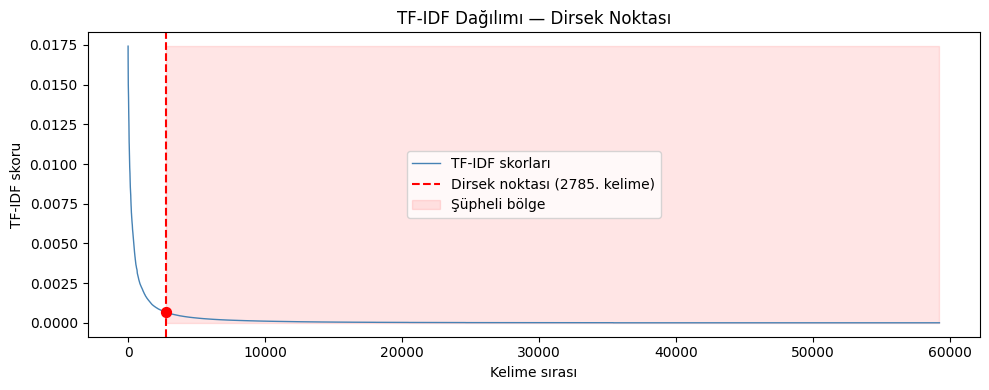

In [8]:
# --- Dirsek noktasını bul ---
# Eğrinin ilk-son noktası arasındaki doğruya en uzak nokta = dirsek
#dirseğin sağı şüpheli -özel korunacalar çıkarılır bu listeden
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def hesapla_tfidf(metin_listesi: list) -> dict:
    N          = len(metin_listesi)
    kelime_tf  = defaultdict(int)
    kelime_df  = defaultdict(int)

    for metin in metin_listesi:
        kelimeler = str(metin).split()
        for k in kelimeler:
            kelime_tf[k] += 1
        for k in set(kelimeler):
            kelime_df[k] += 1

    max_f = max(kelime_tf.values()) if kelime_tf else 1

    return {
        k: math.log10(1 + f / max_f) * math.log10(N / kelime_df[k])
        for k, f in kelime_tf.items()
        if kelime_df[k] > 0
    }

tfidf = hesapla_tfidf(df['lemma'].tolist())
print(f"TF-IDF hesaplandı: {len(tfidf):,} benzersiz kelime")
def dirsek_esigi_bul(skorlar: list) -> tuple:
    if len(skorlar) < 3:
        return 0.0, 0

    skorlar_sirali = sorted(skorlar, reverse=True)
    n              = len(skorlar_sirali)
    coords         = np.vstack((range(n), skorlar_sirali)).T

    first, last = coords[0], coords[-1]
    line        = last - first
    line_norm   = line / np.linalg.norm(line)
    vecs        = coords - first
    proj        = np.outer(np.dot(vecs, line_norm), line_norm)
    dist        = np.linalg.norm(vecs - proj, axis=1)

    dirsek_idx  = np.argmax(dist)
    dirsek_skor = skorlar_sirali[dirsek_idx]

    return dirsek_skor, dirsek_idx


dirsek_skor, dirsek_idx = dirsek_esigi_bul(list(tfidf.values()))

# Şüpheliler: dirsek noktasının SAĞINDA kalanlar — kırılmadan sonraki düşük skorlular
skorlar_sirali = sorted(tfidf.values(), reverse=True)
supheliler = set(
    k for k, s in tfidf.items()
    if s < dirsek_skor and k not in ozel_korunacaklar
)

print(f"Dirsek noktası   : {dirsek_idx}. kelime, skor={dirsek_skor:.4f}")
print(f"Şüpheli kelime   : {len(supheliler):,}")

# --- Grafik ---
plt.figure(figsize=(10, 4))
plt.plot(skorlar_sirali, linewidth=1, color='steelblue', label='TF-IDF skorları')
plt.axvline(x=dirsek_idx, color='red', linestyle='--', linewidth=1.5,
            label=f'Dirsek noktası ({dirsek_idx}. kelime)')
plt.scatter([dirsek_idx], [dirsek_skor], color='red', zorder=5, s=50)
plt.fill_betweenx([0, max(skorlar_sirali)],
                  dirsek_idx, len(skorlar_sirali),
                  alpha=0.1, color='red', label='Şüpheli bölge')
plt.xlabel('Kelime sırası')
plt.ylabel('TF-IDF skoru')
plt.title('TF-IDF Dağılımı — Dirsek Noktası')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
#WORD2VEC
#Cümleden çıkınca anlam bozuluyor mu

from gensim.models import Word2Vec


# Tokenize et — düzeltilmiş ama kök korunmuş veri
tokenized = [str(m).split() for m in df['duzeltilmis'].tolist() if str(m).strip()]

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,   # vektör boyutu
    window=5,          # her iki yönde 5 kelime bağlam penceresi
    min_count=2,       # nadir kelimeleri atla — gürültü azalır
    sg=0,              # CBOW — Türkçe için daha iyi
    workers=4,
    epochs=10
)

print(f"Word2Vec eğitildi")
print(f"   Öğrenilen kelime: {len(w2v_model.wv):,}")

# Kontrol — benzer kelimeler mantıklı mı?
test_kelimeleri = ['iyi', 'kötü', 'güzel', 'hızlı']
for kelime in test_kelimeleri:
    if kelime in w2v_model.wv:
        benzerler = [k for k, _ in w2v_model.wv.most_similar(kelime, topn=3)]
        print(f"   '{kelime}' → {benzerler}")

✅ Word2Vec eğitildi
   Öğrenilen kelime: 135,017
   'iyi' → ['kötü', 'harika', 'güçlü']
   'kötü' → ['iyi', 'berbat', 'korkunç']
   'güzel' → ['muhteşem', 'harika', 'güzeldi']
   'hızlı' → ['ağır', 'akıcı', 'tempoda']


In [10]:
#DİNAMİK EŞİK VE BAPLAMSAL FİLTRE



import numpy as np
from numpy.linalg import norm
from tqdm import tqdm

#Cümleyi temsil eden tek bir anlamsal vektör
def cumle_vektoru(kelimeler: list) -> np.ndarray:
    # Cümledeki kelimelerin vektörlerinin ortalaması
    vek = [w2v_model.wv[k] for k in kelimeler if k in w2v_model.wv]
    return np.mean(vek, axis=0) if vek else np.zeros(w2v_model.vector_size)

#2 cümle anlamsal olarak ne kadar benzer
def kosinus(v1: np.ndarray, v2: np.ndarray) -> float:
    n1, n2 = norm(v1), norm(v2)
    return float(np.dot(v1, v2) / (n1 * n2)) if n1 and n2 else 0.0


#Kelime uzunsa eşik yukarı kısaysa aşşağı
def dinamik_esik(uzunluk: int) -> float:
    # 3  kelime → 0.80  (kısa cümle, gevşek — agresif sil)
    # 10 kelime → 0.92
    # 30 kelime → 0.97  (uzun cümle, sıkı — dikkatli sil)
    return 1.0 - (0.6 / (uzunluk + 2))

#karar : 2 veya daha aza düştüyse silme artık
#özel korunacaklardaysa atla
#benzerlik => esik ise kelimeyi sil
def baglamsal_filtre(metin: str) -> str:
    metin = str(metin)
    kelimeler = metin.split()
    if not kelimeler:
        return metin

    guncel = kelimeler.copy()

    for aday in [k for k in kelimeler if k in supheliler]:
        # Cümle çok kısaldıysa  — anlam kaybolabilir
        if len(guncel) <= 2:
            break

        # Özel korunacak listeye tekrar bak
        if aday in ozel_korunacaklar:
            continue

        vec_tam   = cumle_vektoru(guncel)
        vec_eksik = cumle_vektoru([k for k in guncel if k != aday])
        benzerlik = kosinus(vec_tam, vec_eksik)
        esik      = dinamik_esik(len(guncel))

        if benzerlik >= esik:
            # Anlam bozulmadı — gerçek stopword, sil
            guncel = [k for k in guncel if k != aday]
        # Anlam bozuldu — koru, dokunma

    return ' '.join(guncel)

# Tüm veri setine uygula
df['filtrelenmis'] = [
    baglamsal_filtre(m)
    for m in tqdm(df['duzeltilmis'].tolist(), desc='Bağlamsal filtre')
]

# Kaç kelime silindi, kaçı korundu
toplam_once = df['duzeltilmis'].apply(lambda x: len(str(x).split())).sum()
toplam_sonra = df['filtrelenmis'].apply(lambda x: len(str(x).split())).sum()

print(f"\n Filtre tamamlandı")
print(f"   Önceki kelime sayısı : {toplam_once:,}")
print(f"   Sonraki kelime sayısı: {toplam_sonra:,}")
print(f"   Silinen              : {toplam_once - toplam_sonra:,} (%{(toplam_once-toplam_sonra)/toplam_once*100:.1f})")

# Örnek — değişen cümleler
print("\nÖrnek filtreler:")
for i in range(5):
    once  = df['duzeltilmis'].iloc[i]
    sonra = df['filtrelenmis'].iloc[i]
    if once != sonra:
        print(f"\n  Önce : {once[:70]}")
        print(f"  Sonra: {sonra[:70]}")

Bağlamsal filtre: 100%|██████████| 49366/49366 [03:34<00:00, 230.40it/s]



✅ Filtre tamamlandı
   Önceki kelime sayısı : 8,462,892
   Sonraki kelime sayısı: 8,115,056
   Silinen              : 347,836 (%4.1)

Örnek filtreler:

  Önce : diğer yorumculardan biri sadece oz bölümünü izledikten sonra bağlanaca
  Sonra: diğer yorumculardan biri sadece oz bölümünü izledikten sonra bağlanaca

  Önce : harika bir küçük prodüksiyon çekim tekniği çok mütevazı çok eski zaman
  Sonra: harika bir küçük prodüksiyon çekim tekniği çok mütevazı çok eski zaman

  Önce : çok sıcak bir yaz hafta sonunda vakit geçirmek için bunun harika bir y
  Sonra: çok sıcak bir yaz hafta sonunda vakit geçirmek için bunun harika bir y

  Önce : temel olarak küçük bir çocuğun jake dolabında bir zombi olduğunu düşün
  Sonra: temel olarak küçük bir çocuğun jake dolabında bir zombi olduğunu düşün

  Önce : petter mattei nin love in the time of money filmi izlenmesi görsel açı
  Sonra: petter mattei nin love in the of money filmi izlenmesi görsel açıdan ç


In [12]:
# === HÜCRE: KLASİK MAKİNE ÖĞRENMESİ KARŞILAŞTIRMALARI ===
import time
import numpy as np
import pandas as pd
import nltk
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

# Sınıflandırıcılar
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# --- Güvenlik Kontrolü: Final Lemma uygulanmış mı? ---
if 'final' not in df.columns:
    print("Final lemma sütunu bulunamadı. Lemmatizasyon uygulanıyor (Bu işlem biraz sürebilir)...")
    tqdm.pandas(desc='Lemmatization')
    df['final'] = df['filtrelenmis'].progress_apply(metin_lemma)
else:
    print("✅ Hazır: 'final' (lemmalı) sütunu zaten mevcut.")

# --- Statik Stopwords Listesini Yükle ---
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
statik_liste = set(stopwords.words('turkish'))

# --- Sınıf Etiketlerini Hazırla ---
le = LabelEncoder()
y = le.fit_transform(df[ETIKET_SUTUNU].values)
print(f"Sınıflar: {le.classes_}\n")

# --- 1. Veri Hazırlığı: Klasik (Statik Stopwords) ---
print("1. Klasik (Statik Stopwords) veri hazırlanıyor...")
klasik_metinler = [
    ' '.join(k for k in str(m).split() if k not in statik_liste)
    for m in df['temiz']
]

# --- 2. Veri Hazırlığı: Dinamik (Geliştirilen Yöntem) ---
print("2. Dinamik (Bizim Yöntem) veri hazırlanıyor...")
dinamik_metinler = df['final'].tolist()

# --- Değerlendirme Fonksiyonu ---
def ml_deneyi(metinler, etiketler, yontem_adi):
    print(f"\n>>> Deney Başladı: {yontem_adi} <<<")

    # TF-IDF Vektörleştirme
    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
    X = vectorizer.fit_transform(metinler)

    # Train-Test Split (Her iki deneyde de aynı bölünme olması için random_state sabit)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, etiketler, test_size=0.2, random_state=42
    )

    modeller = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Naive Bayes (MNB)": MultinomialNB(),
        "Linear SVM (SVC)": LinearSVC(dual=False, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=25, n_jobs=-1, random_state=42)
    }

    sonuclar = {}
    for isim, model in modeller.items():
        t0 = time.time()
        # Eğitim
        model.fit(X_tr, y_tr)
        sure_egitim = time.time() - t0

        # Tahmin ve Skorlama
        tahmin = model.predict(X_te)
        acc = accuracy_score(y_te, tahmin)
        f1 = f1_score(y_te, tahmin, average='weighted')

        sonuclar[isim] = {
            'Accuracy': acc,
            'F1-Score': f1,
            'Süre (sn)': sure_egitim
        }
        print(f"  {isim:<20} -> Acc: %{acc*100:.2f} | F1: %{f1*100:.2f} | Süre: {sure_egitim:.2f}s")

    return sonuclar

# --- Deneyleri Çalıştır ---
klasik_sonuclar = ml_deneyi(klasik_metinler, y, "Klasik (Statik Stopwords)")
dinamik_sonuclar = ml_deneyi(dinamik_metinler, y, "Dinamik (Bizim Yöntem)")

# --- KARŞILAŞTIRMA TABLOSUNU BAS ---
print(f"\n\n{'='*75}")
print(f"{'Algoritma':<22} | {'Yöntem':<10} | {'Accuracy':^12} | {'F1-Score':^12} | {'Süre (sn)':^10}")
print(f"{'-'*75}")

for model_adi in klasik_sonuclar.keys():
    k = klasik_sonuclar[model_adi]
    d = dinamik_sonuclar[model_adi]

    print(f"{model_adi:<22} | {'Klasik':<10} | %{k['Accuracy']*100:>8.2f} | %{k['F1-Score']*100:>8.2f} | {k['Süre (sn)']:>8.2f}s")
    print(f"{model_adi:<22} | {'Dinamik':<10} | %{d['Accuracy']*100:>8.2f} | %{d['F1-Score']*100:>8.2f} | {d['Süre (sn)']:>8.2f}s")
    print(f"{'-'*75}")

print(f"{'='*75}")

Final lemma sütunu bulunamadı. Lemmatizasyon uygulanıyor (Bu işlem biraz sürebilir)...


Lemmatization: 100%|██████████| 49366/49366 [08:12<00:00, 100.32it/s]


Sınıflar: ['negatif' 'pozitif']

1. Klasik (Statik Stopwords) veri hazırlanıyor...
2. Dinamik (Bizim Yöntem) veri hazırlanıyor...

>>> Deney Başladı: Klasik (Statik Stopwords) <<<
  Logistic Regression  -> Acc: %90.59 | F1: %90.59 | Süre: 14.25s
  Naive Bayes (MNB)    -> Acc: %88.48 | F1: %88.48 | Süre: 0.10s
  Linear SVM (SVC)     -> Acc: %89.95 | F1: %89.95 | Süre: 8.49s
  Random Forest        -> Acc: %85.02 | F1: %85.01 | Süre: 4.71s

>>> Deney Başladı: Dinamik (Bizim Yöntem) <<<
  Logistic Regression  -> Acc: %90.05 | F1: %90.05 | Süre: 15.15s
  Naive Bayes (MNB)    -> Acc: %87.83 | F1: %87.83 | Süre: 0.03s
  Linear SVM (SVC)     -> Acc: %89.46 | F1: %89.46 | Süre: 10.37s
  Random Forest        -> Acc: %85.73 | F1: %85.73 | Süre: 8.39s


Algoritma              | Yöntem     |   Accuracy   |   F1-Score   | Süre (sn) 
---------------------------------------------------------------------------
Logistic Regression    | Klasik     | %   90.59 | %   90.59 |    14.25s
Logistic Regression  